In [3]:
"""
Download W&B run histories for Navigation experiments.

Run naming:
  AD2C:             3agent{n}goal_seed{m}         (n=1..3, m=0..4)
  DiCo:             nav_dico_3a3g_1, nav_dico_3a2g_0.8, nav_dico_3a1g_0
  Unconstrained:    nav_dico_3a{n}g_-1            (n=1..3)

Usage:
  pip install wandb pandas
  wandb login
  python download_wandb_data.py
"""

import pandas as pd
import wandb
import os

# ============================================================
# CONFIG
# ============================================================
ENTITY_PROJECT = "svarp-university-of-massachusetts-lowell/Navigation"
OUTPUT_DIR = "navigation_data"

# All run names we need, organized by method and task
RUNS_TO_FETCH = {
    "ad2c": {
        "3A-3G": [f"3agent3goal_seed{m}" for m in range(5)],
        "3A-2G": [f"3agent2goal_seed{m}" for m in range(5)],
        "3A-1G": [f"3agent1goal_seed{m}" for m in range(5)],
    },
    "dico": {
        "3A-3G": ["nav_dico_3a3g_1"],
        "3A-2G": ["nav_dico_3a2g_0.8"],
        "3A-1G": ["nav_dico_3a1g_0"],
    },
    "unconstrained": {
        "3A-3G": ["nav_dico_3a3g_-1"],
        "3A-2G": ["nav_dico_3a2g_-1"],
        "3A-1G": ["nav_dico_3a1g_-1"],
    },
}

# ============================================================
# MAIN
# ============================================================

def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    api = wandb.Api()

    # Step 1: Get all runs and build a name -> run lookup
    print(f"Fetching run list from {ENTITY_PROJECT}...")
    runs = api.runs(ENTITY_PROJECT)

    run_lookup = {}
    for run in runs:
        run_lookup[run.name] = run

    print(f"Found {len(run_lookup)} total runs.")
    print(f"Run names: {list(run_lookup.keys())[:20]}...\n")

    # Step 2: Download history for each run we need
    found = 0
    missing = []

    for method, task_variants in RUNS_TO_FETCH.items():
        for task_label, run_names in task_variants.items():
            for run_name in run_names:

                if run_name not in run_lookup:
                    missing.append(f"{method}/{task_label}/{run_name}")
                    print(f"  MISSING: '{run_name}'")
                    continue

                run = run_lookup[run_name]
                print(f"Downloading: {method} / {task_label} / {run_name} ...", end=" ")

                try:
                    # samples=10000 to get all/most data points
                    df = run.history(samples=10000)
                except Exception as e:
                    print(f"ERROR: {e}")
                    missing.append(f"{method}/{task_label}/{run_name} (download failed)")
                    continue

                # Save CSV
                safe_name = run_name.replace(".", "p").replace("-", "neg")
                filename = f"{method}_{task_label}_{safe_name}.csv"
                filepath = os.path.join(OUTPUT_DIR, filename)
                df.to_csv(filepath, index=False)

                print(f"OK ({len(df)} rows)")
                found += 1

    # Step 3: Summary
    print(f"\n{'='*60}")
    print(f"Downloaded: {found} runs")
    print(f"Missing:    {len(missing)} runs")
    if missing:
        print("\nMissing runs:")
        for m in missing:
            print(f"  - {m}")

    # Step 4: Print columns from first file so we know metric names
    csv_files = [f for f in os.listdir(OUTPUT_DIR) if f.endswith('.csv')]
    if csv_files:
        ref = pd.read_csv(os.path.join(OUTPUT_DIR, csv_files[0]))
        print(f"\nColumns from {csv_files[0]}:")
        for col in sorted(ref.columns):
            print(f"  {col}")

    print(f"\nAll CSVs saved to ./{OUTPUT_DIR}/")
    print("Upload this folder back to Claude for plotting.")


if __name__ == "__main__":
    main()

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/grad/doc/2027/spatel2/.netrc.


Fetching run list from svarp-university-of-massachusetts-lowell/Navigation...
Found 57 total runs.
Run names: ['navigation_3agent3goal_-1', 'navigation_3agent2goal_-1', 'navigation_3agent1goal_-1', 'nav_esc_3a3g_0', 'nav_esc_3a2g_0', 'nav_esc_3a1g_0', 'nav_esc_3a3g_0.5', 'nav_esc_3a3g_1', 'nav_esc_3a3g_1.3', 'nav_esc_3a2g_1', 'nav_esc_3a2g_0.5', 'nav_esc_3a2g_1.3', 'nav_esc_3a1g_0.5', 'nav_esc_3a1g_1', 'nav_esc_3a1g_1.3', 'nav_dico_3a3g_0', 'nav_dico_3a2g_0', 'nav_dico_3a1g_0', 'nav_dico_3a3g_0.3', 'nav_dico_3a2g_0.3']...

Downloading: ad2c / 3A-3G / 3agent3goal_seed0 ... OK (200 rows)
Downloading: ad2c / 3A-3G / 3agent3goal_seed1 ... OK (200 rows)
Downloading: ad2c / 3A-3G / 3agent3goal_seed2 ... OK (200 rows)
Downloading: ad2c / 3A-3G / 3agent3goal_seed3 ... OK (200 rows)
Downloading: ad2c / 3A-3G / 3agent3goal_seed4 ... OK (200 rows)
Downloading: ad2c / 3A-2G / 3agent2goal_seed0 ... OK (200 rows)
Downloading: ad2c / 3A-2G / 3agent2goal_seed1 ... OK (200 rows)
Downloading: ad2c / 3A-

In [4]:
"""
Download ONLY the 3 missing unconstrained runs.
Run this in the same directory as the navigation_data folder.

The unconstrained runs are named:
  navigation_3agent3goal_-1  (not nav_dico_3a3g_-1)
  navigation_3agent2goal_-1
  navigation_3agent1goal_-1
"""

import pandas as pd
import wandb
import os

ENTITY_PROJECT = "svarp-university-of-massachusetts-lowell/Navigation"
OUTPUT_DIR = "navigation_data"

UNCONSTRAINED_RUNS = {
    "3A-3G": "navigation_3agent3goal_-1",
    "3A-2G": "navigation_3agent2goal_-1",
    "3A-1G": "navigation_3agent1goal_-1",
}

def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    api = wandb.Api()

    print(f"Fetching run list from {ENTITY_PROJECT}...")
    runs = api.runs(ENTITY_PROJECT)
    run_lookup = {run.name: run for run in runs}

    for task_label, run_name in UNCONSTRAINED_RUNS.items():
        if run_name not in run_lookup:
            print(f"  MISSING: '{run_name}'")
            continue

        run = run_lookup[run_name]
        print(f"Downloading: unconstrained / {task_label} / {run_name} ...", end=" ")

        df = run.history(samples=10000)

        safe_name = run_name.replace(".", "p").replace("-", "neg")
        filename = f"unconstrained_{task_label}_{safe_name}.csv"
        filepath = os.path.join(OUTPUT_DIR, filename)
        df.to_csv(filepath, index=False)
        print(f"OK ({len(df)} rows)")

    print("Done! Now you have all 21 CSVs.")

if __name__ == "__main__":
    main()

Fetching run list from svarp-university-of-massachusetts-lowell/Navigation...
Downloading: unconstrained / 3A-3G / navigation_3agent3goal_-1 ... OK (200 rows)
Downloading: unconstrained / 3A-2G / navigation_3agent2goal_-1 ... OK (200 rows)
Downloading: unconstrained / 3A-1G / navigation_3agent1goal_-1 ... OK (200 rows)
Done! Now you have all 21 CSVs.


Loading data...
  ad2c / 3A-1G: 5 seeds
  ad2c / 3A-2G: 5 seeds
  ad2c / 3A-3G: 5 seeds
  dico / 3A-3G: 1 run
  dico / 3A-2G: 1 run
  dico / 3A-1G: 1 run
  unconstrained / 3A-1G: 1 runs
  unconstrained / 3A-2G: 1 runs
  unconstrained / 3A-3G: 1 runs

Loaded 9 method-task combinations.

Plotting navigation results...
Saved: navigation_results.png
Saved: navigation_results.pdf


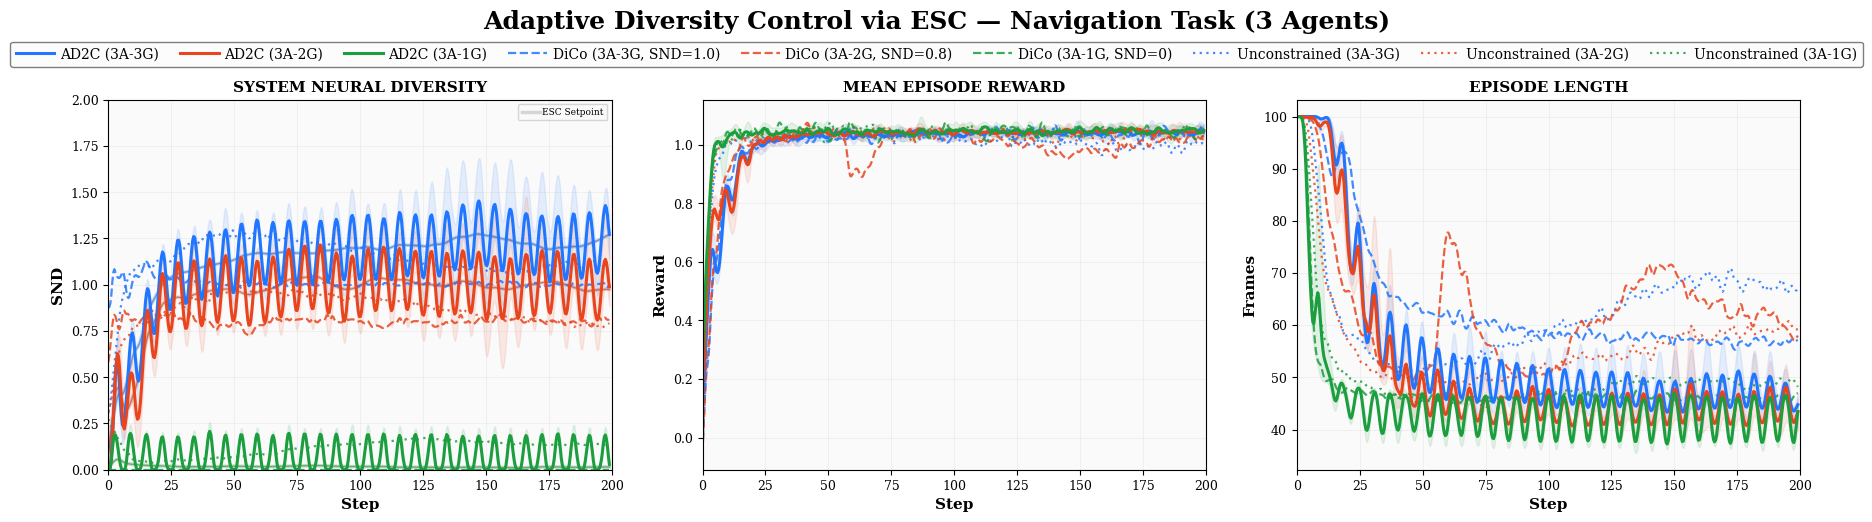

In [65]:
"""
Plot Navigation Results: AD2C vs DiCo vs Unconstrained
3 subplots in one row: SND, Reward, Episode Length
9 lines per plot + SND setpoint overlay for AD2C

Usage:
  python plot_navigation_v2.py
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib
import glob
import os

# ============================================================
# STYLE CONFIG
# ============================================================
matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman', 'Times New Roman', 'DejaVu Serif'],
    'text.usetex': False,
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'legend.fontsize': 7,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linewidth': 0.4,
    'axes.facecolor': '#fafafa',
})

# ============================================================
# COLOR SCHEME — distinct per task, readable in print & colorblind-friendly
# ============================================================
# Task colors: blue / red-orange / green — high contrast, colorblind safe
COLORS = {
    "3A-3G": "#2176FF",   # strong blue
    "3A-2G": "#E8451E",   # red-orange
    "3A-1G": "#1B9E3E",   # green
}

# Lighter shades for shaded bands
FILL_COLORS = {
    "3A-3G": "#2176FF",
    "3A-2G": "#E8451E",
    "3A-1G": "#1B9E3E",
}

# Line styles: clearly distinct per method
LINE_STYLES = {
    "ad2c":          {"linestyle": "-",       "linewidth": 2.2, "alpha": 1.0},
    "dico":          {"linestyle": "--",      "linewidth": 1.6, "alpha": 0.85},
    "unconstrained": {"linestyle": (0,(1,2)), "linewidth": 1.6, "alpha": 0.85},  # tight dotted
}

# Legend labels
LABELS = {
    ("ad2c", "3A-3G"):          "AD2C (3A-3G)",
    ("ad2c", "3A-2G"):          "AD2C (3A-2G)",
    ("ad2c", "3A-1G"):          "AD2C (3A-1G)",
    ("dico", "3A-3G"):          "DiCo (3A-3G, SND=1.0)",
    ("dico", "3A-2G"):          "DiCo (3A-2G, SND=0.8)",
    ("dico", "3A-1G"):          "DiCo (3A-1G, SND=0)",
    ("unconstrained", "3A-3G"): "Unconstrained (3A-3G)",
    ("unconstrained", "3A-2G"): "Unconstrained (3A-2G)",
    ("unconstrained", "3A-1G"): "Unconstrained (3A-1G)",
}

# Desired legend order (AD2C first, then DiCo, then Unconstrained, then setpoint)
LEGEND_ORDER = [
    ("ad2c", "3A-3G"), ("ad2c", "3A-2G"), ("ad2c", "3A-1G"),
    ("dico", "3A-3G"), ("dico", "3A-2G"), ("dico", "3A-1G"),
    ("unconstrained", "3A-3G"), ("unconstrained", "3A-2G"), ("unconstrained", "3A-1G"),
]

# Metric column names
METRICS = {
    "snd":    "eval/agents/snd",
    "reward": "eval/agents/reward/episode_reward_mean",
    "epl":    "eval/reward/episode_len_mean",
}

SETPOINT_COL = "esc/snd_setpoint"
STEP_COL = "_step"

SMOOTH_WINDOW = 5          # default for reward/epl
SMOOTH_WINDOW_SND = 3      # lighter smoothing for SND to show ESC perturbations
DATA_DIR = "navigation_data"

# ============================================================
# DATA LOADING
# ============================================================

def load_runs(data_dir):
    """Load all CSVs and organize by (method, task_variant)."""
    data = {}

    # AD2C: multiple seeds per task
    for task in ["3A-1G", "3A-2G", "3A-3G"]:
        pattern = os.path.join(data_dir, f"ad2c_{task}_*.csv")
        files = sorted(glob.glob(pattern))
        if files:
            data[("ad2c", task)] = [pd.read_csv(f) for f in files]
            print(f"  ad2c / {task}: {len(files)} seeds")

    # DiCo: single run per task
    dico_files = {
        "3A-3G": "dico_3A-3G_nav_dico_3a3g_1.csv",
        "3A-2G": "dico_3A-2G_nav_dico_3a2g_0p8.csv",
        "3A-1G": "dico_3A-1G_nav_dico_3a1g_0.csv",
    }
    for task, fname in dico_files.items():
        fpath = os.path.join(data_dir, fname)
        if os.path.exists(fpath):
            data[("dico", task)] = [pd.read_csv(fpath)]
            print(f"  dico / {task}: 1 run")

    # Unconstrained: single run per task
    for task in ["3A-1G", "3A-2G", "3A-3G"]:
        pattern = os.path.join(data_dir, f"unconstrained_{task}_*.csv")
        files = sorted(glob.glob(pattern))
        if files:
            data[("unconstrained", task)] = [pd.read_csv(f) for f in files]
            print(f"  unconstrained / {task}: {len(files)} runs")

    return data


def smooth(y, window=SMOOTH_WINDOW):
    """Rolling average smoothing with edge padding."""
    if window <= 1 or len(y) < window:
        return y
    kernel = np.ones(window) / window
    padded = np.pad(y, (window // 2, window // 2), mode='edge')
    smoothed = np.convolve(padded, kernel, mode='valid')
    return smoothed[:len(y)]


def aggregate_seeds(dfs, metric_col, step_col=STEP_COL, n_points=500, smooth_window=SMOOTH_WINDOW):
    """Interpolate seeds onto common grid, return mean/min/max."""
    valid_dfs = []
    for df in dfs:
        if metric_col in df.columns and step_col in df.columns:
            sub = df[[step_col, metric_col]].dropna().sort_values(step_col)
            if len(sub) >= 2:
                valid_dfs.append(sub)

    if not valid_dfs:
        return None, None, None, None

    min_step = max(df[step_col].min() for df in valid_dfs)
    max_step = min(df[step_col].max() for df in valid_dfs)
    common_steps = np.linspace(min_step, max_step, n_points)

    interpolated = []
    for sub in valid_dfs:
        vals = np.interp(common_steps, sub[step_col].values, sub[metric_col].values)
        interpolated.append(vals)

    interpolated = np.array(interpolated)
    mean = np.mean(interpolated, axis=0)
    vmin = np.min(interpolated, axis=0)
    vmax = np.max(interpolated, axis=0)

    return common_steps, smooth(mean, smooth_window), smooth(vmin, smooth_window), smooth(vmax, smooth_window)


def aggregate_setpoint(dfs, step_col=STEP_COL, n_points=500):
    """Aggregate the ESC setpoint across seeds."""
    valid_dfs = []
    for df in dfs:
        if SETPOINT_COL in df.columns and step_col in df.columns:
            sub = df[[step_col, SETPOINT_COL]].dropna().sort_values(step_col)
            if len(sub) >= 2:
                valid_dfs.append(sub)

    if not valid_dfs:
        return None, None

    min_step = max(df[step_col].min() for df in valid_dfs)
    max_step = min(df[step_col].max() for df in valid_dfs)
    common_steps = np.linspace(min_step, max_step, n_points)

    interpolated = []
    for sub in valid_dfs:
        vals = np.interp(common_steps, sub[step_col].values, sub[SETPOINT_COL].values)
        interpolated.append(vals)

    interpolated = np.array(interpolated)
    mean = np.mean(interpolated, axis=0)

    return common_steps, smooth(mean, window=11)


# ============================================================
# PLOTTING
# ============================================================

def plot_metric(ax, data, metric_key, ylabel, title, ylim=None, show_setpoint=False, smooth_window=SMOOTH_WINDOW):
    """Plot all 9 lines on one axes, optionally with SND setpoint."""

    metric_col = METRICS[metric_key]

    # Plot order: unconstrained (back), dico (mid), ad2c (front)
    plot_order = [
        ("unconstrained", "3A-3G"), ("unconstrained", "3A-2G"), ("unconstrained", "3A-1G"),
        ("dico", "3A-3G"), ("dico", "3A-2G"), ("dico", "3A-1G"),
        ("ad2c", "3A-3G"), ("ad2c", "3A-2G"), ("ad2c", "3A-1G"),
    ]

    for method, task in plot_order:
        key = (method, task)
        if key not in data:
            continue

        steps, mean, vmin, vmax = aggregate_seeds(data[key], metric_col, smooth_window=smooth_window)
        if steps is None:
            continue

        color = COLORS[task]
        style = LINE_STYLES[method]
        label = LABELS.get(key, f"{method} {task}")

        ax.plot(steps, mean, color=color, label=label,
                linestyle=style["linestyle"],
                linewidth=style["linewidth"],
                alpha=style["alpha"])

        # Shaded band for AD2C (multiple seeds)
        if method == "ad2c":
            ax.fill_between(steps, vmin, vmax, color=color, alpha=0.10)

    # Overlay SND setpoint as a thin dark line behind AD2C (same color, no extra legend)
    if show_setpoint:
        for task in ["3A-3G", "3A-2G", "3A-1G"]:
            key = ("ad2c", task)
            if key not in data:
                continue
            steps, sp_mean = aggregate_setpoint(data[key])
            if steps is None:
                continue
            # Draw setpoint: same color but darker, thin dash-dot, behind the SND line
            # Use zorder to place behind the main AD2C line
            ax.plot(steps, sp_mean,
                    color='black',
                    linestyle='-',
                    linewidth=1.0,
                    alpha=0.35,
                    zorder=1)
            # Also draw in the task color so it's visible
            ax.plot(steps, sp_mean,
                    color=COLORS[task],
                    linestyle='-',
                    linewidth=2.5,
                    alpha=0.3,
                    zorder=1)

    ax.set_xlabel("Step", fontweight='bold')
    ax.set_ylabel(ylabel, fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlim(left=0, right=200)
    if ylim:
        ax.set_ylim(ylim)


def make_navigation_figure(data, output_prefix="navigation"):
    """Create the full-width 3-panel figure."""

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=False)
    fig.subplots_adjust(left=0.04, right=0.98, bottom=0.08, top=0.82, wspace=0.18)

    # Plot 1: SND (with setpoint overlay, lighter smoothing to show perturbations)
    plot_metric(axes[0], data, "snd",
                ylabel="SND",
                title="SYSTEM NEURAL DIVERSITY",
                ylim=(0, 2.0),
                show_setpoint=True,
                smooth_window=SMOOTH_WINDOW_SND)

    # Plot 2: Reward
    plot_metric(axes[1], data, "reward",
                ylabel="Reward",
                title="MEAN EPISODE REWARD")

    # Plot 3: Episode Length
    plot_metric(axes[2], data, "epl",
                ylabel="Frames",
                title="EPISODE LENGTH")
    
    sp_handle = mlines.Line2D([], [], color='gray', linewidth=2.5, alpha=0.3,
                               linestyle='-', label='ESC Setpoint')
    axes[0].legend(handles=[sp_handle], labels=['ESC Setpoint'],
                   loc='upper right', fontsize=6.5, frameon=True,
                   fancybox=True, framealpha=0.8, edgecolor='#cccccc',
                   handlelength=2.0, handletextpad=0.3)

    # Build combined legend — reorder to: AD2C, DiCo, Unconstrained, Setpoint
    raw_handles, raw_labels = axes[0].get_legend_handles_labels()
    label_to_handle = dict(zip(raw_labels, raw_handles))

    # Reorder according to LEGEND_ORDER
    ordered_handles = []
    ordered_labels = []
    for key in LEGEND_ORDER:
        lbl = LABELS.get(key)
        if lbl and lbl in label_to_handle:
            ordered_handles.append(label_to_handle[lbl])
            ordered_labels.append(lbl)

    # Two-line legend: 5 per row, positioned in the top margin
    fig.legend(ordered_handles, ordered_labels,
               loc='upper center',
               ncol=9,
               bbox_to_anchor=(0.5, 0.95),
               fontsize=10,
               frameon=True,
               fancybox=True,
               edgecolor='black',
               framealpha=0.5,
               columnspacing=1.5,
               handlelength=2.8,
               handletextpad=0.4,
               borderpad=0.4,
               labelspacing=0.35)

    # Figure title
    fig.suptitle(
        'Adaptive Diversity Control via ESC — Navigation Task (3 Agents)',
        fontsize=18, fontweight='bold', y=1.0)

    # Save
    for ext in ['png', 'pdf']:
        outpath = f"{output_prefix}_results.{ext}"
        fig.savefig(outpath, dpi=300, bbox_inches='tight')
        print(f"Saved: {outpath}")

    plt.show()


# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":
    print("Loading data...")
    data = load_runs(DATA_DIR)
    print(f"\nLoaded {len(data)} method-task combinations.\n")

    print("Plotting navigation results...")
    make_navigation_figure(data, output_prefix="navigation")

# Part 2: Convergence Plot

In [17]:
"""
Download convergence analysis runs: AD2C with different initial SND setpoints.
Runs: nav_esc_3a3g_{0, 0.5, 1, 1.3, 1.5} (note: not 1.0, check exact naming)
"""

import pandas as pd
import wandb
import os

ENTITY_PROJECT = "svarp-university-of-massachusetts-lowell/Navigation"
OUTPUT_DIR = "convergence_data"

# Initial SND setpoints to fetch
INITIAL_SNDS = ["0", "0.5", "1", "1.3", "1.5"]

def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    api = wandb.Api()

    print(f"Fetching run list from {ENTITY_PROJECT}...")
    runs = api.runs(ENTITY_PROJECT)
    run_lookup = {run.name: run for run in runs}

    # Print all nav_esc runs for debugging
    print("\nAvailable nav_esc_3a3g runs:")
    for name in sorted(run_lookup.keys()):
        if "nav_esc_3a3g" in name:
            print(f"  {name}")
    print()

    for snd in INITIAL_SNDS:
        run_name = f"nav_esc_3a3g_{snd}"

        if run_name not in run_lookup:
            print(f"  MISSING: '{run_name}'")
            continue

        run = run_lookup[run_name]
        print(f"Downloading: {run_name} ...", end=" ")

        df = run.history(samples=10000)

        safe_name = run_name.replace(".", "p")
        filepath = os.path.join(OUTPUT_DIR, f"{safe_name}.csv")
        df.to_csv(filepath, index=False)
        print(f"OK ({len(df)} rows)")

    print(f"\nAll CSVs saved to ./{OUTPUT_DIR}/")

if __name__ == "__main__":
    main()

Fetching run list from svarp-university-of-massachusetts-lowell/Navigation...

Available nav_esc_3a3g runs:
  nav_esc_3a3g_0
  nav_esc_3a3g_0.5
  nav_esc_3a3g_1
  nav_esc_3a3g_1.3
  nav_esc_3a3g_1.5

Downloading: nav_esc_3a3g_0 ... OK (200 rows)
Downloading: nav_esc_3a3g_0.5 ... OK (200 rows)
Downloading: nav_esc_3a3g_1 ... OK (200 rows)
Downloading: nav_esc_3a3g_1.3 ... OK (200 rows)
Downloading: nav_esc_3a3g_1.5 ... OK (200 rows)

All CSVs saved to ./convergence_data/


Loading convergence data...
  Loaded nav_esc_3a3g_0.csv (200 rows)
  Loaded nav_esc_3a3g_0p5.csv (200 rows)
  Loaded nav_esc_3a3g_1.csv (200 rows)
  Loaded nav_esc_3a3g_1p3.csv (200 rows)
  Loaded nav_esc_3a3g_1p5.csv (200 rows)

Loaded 5 runs.

Plotting convergence analysis...


Saved: convergence_nav.png
Saved: convergence_nav.pdf


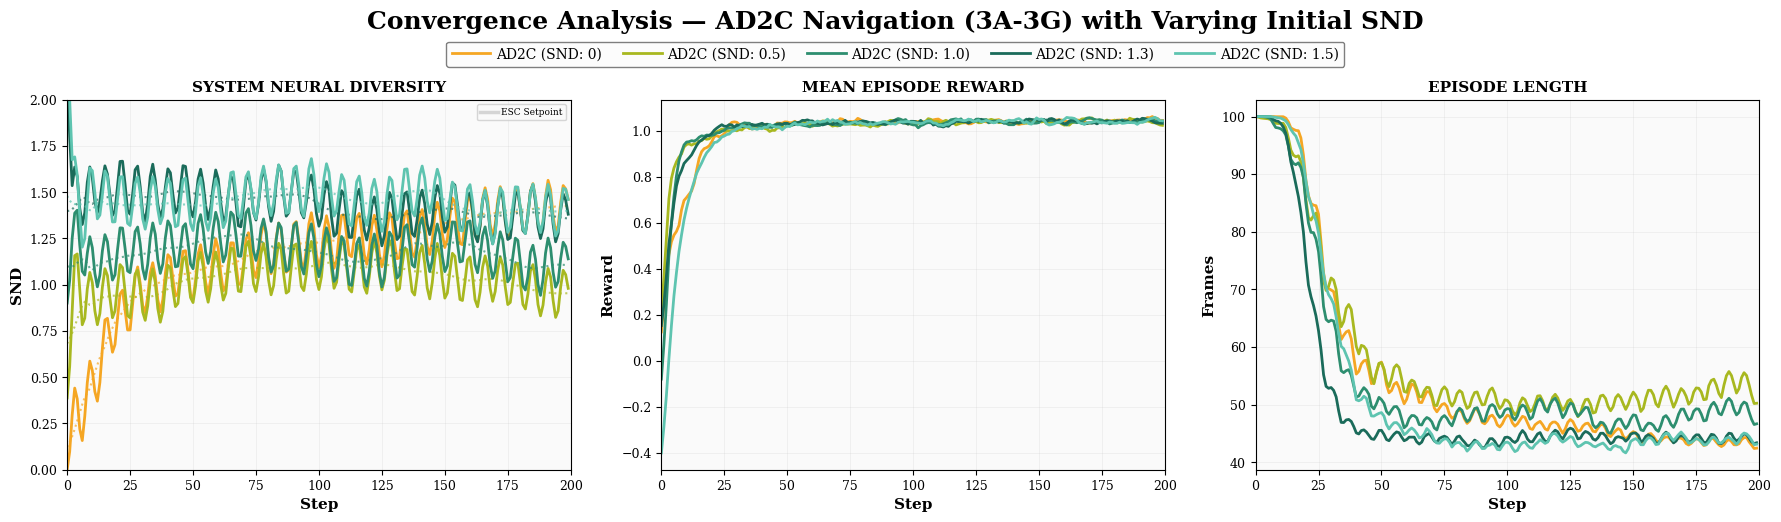

In [64]:
"""
Convergence Analysis Plot: AD2C (3A-3G) with different initial SND setpoints.
Shows that AD2C converges to the same optimal diversity regardless of initialization.

3 subplots: SND (with setpoint overlay), Reward, Episode Length
Each line = different initial SND (0, 0.5, 1.0, 1.3, 1.5)

Usage:
  python plot_convergence.py
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.lines as mlines
import os

# ============================================================
# STYLE
# ============================================================
matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman', 'Times New Roman', 'DejaVu Serif'],
    'text.usetex': False,
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'legend.fontsize': 8,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linewidth': 0.4,
    'axes.facecolor': '#fafafa',
})

# ============================================================
# CONFIG
# ============================================================
DATA_DIR = "convergence_data"

# Initial SND values and their display labels
INITIAL_SNDS = {
    "0":   {"label": "AD2C (SND: 0)",   "file": "nav_esc_3a3g_0.csv"},
    "0.5": {"label": "AD2C (SND: 0.5)", "file": "nav_esc_3a3g_0p5.csv"},
    "1":   {"label": "AD2C (SND: 1.0)", "file": "nav_esc_3a3g_1.csv"},
    "1.3": {"label": "AD2C (SND: 1.3)", "file": "nav_esc_3a3g_1p3.csv"},
    "1.5": {"label": "AD2C (SND: 1.5)", "file": "nav_esc_3a3g_1p5.csv"},
}

# Color gradient: orange → yellow-green → teal → dark teal → light teal
# Matching the reference images
COLORS = {
    "0":   "#F5A623",   # orange
    "0.5": "#A8B820",   # yellow-green
    "1":   "#2D8E6F",   # dark green-teal
    "1.3": "#1A6B5A",   # darker teal
    "1.5": "#5EC4B0",   # light teal
}

# Metric columns
METRICS = {
    "snd":    "eval/agents/snd",
    "reward": "eval/agents/reward/episode_reward_mean",
    "epl":    "eval/reward/episode_len_mean",
}
SETPOINT_COL = "esc/snd_setpoint"
STEP_COL = "_step"

SMOOTH_WINDOW = 5
SMOOTH_WINDOW_SND = 3

# ============================================================
# HELPERS
# ============================================================

def smooth(y, window=SMOOTH_WINDOW):
    if window <= 1 or len(y) < window:
        return y
    kernel = np.ones(window) / window
    padded = np.pad(y, (window // 2, window // 2), mode='edge')
    smoothed = np.convolve(padded, kernel, mode='valid')
    return smoothed[:len(y)]


def load_data():
    """Load all convergence CSVs."""
    data = {}
    for snd_key, info in INITIAL_SNDS.items():
        fpath = os.path.join(DATA_DIR, info["file"])
        if os.path.exists(fpath):
            data[snd_key] = pd.read_csv(fpath)
            print(f"  Loaded {info['file']} ({len(data[snd_key])} rows)")
        else:
            print(f"  MISSING: {fpath}")
    return data


# ============================================================
# PLOTTING
# ============================================================

def plot_metric(ax, data, metric_key, ylabel, title, ylim=None,
                show_setpoint=False, sw=SMOOTH_WINDOW):
    """Plot one metric for all initial SND values."""

    metric_col = METRICS[metric_key]

    for snd_key, info in INITIAL_SNDS.items():
        if snd_key not in data:
            continue

        df = data[snd_key]
        if metric_col not in df.columns or STEP_COL not in df.columns:
            print(f"  WARNING: Missing {metric_col} in {info['file']}")
            continue

        sub = df[[STEP_COL, metric_col]].dropna().sort_values(STEP_COL)
        steps = sub[STEP_COL].values
        vals = smooth(sub[metric_col].values, window=sw)

        color = COLORS[snd_key]
        label = info["label"]

        ax.plot(steps, vals, color=color, linewidth=2.0, label=label)

        # Setpoint overlay on SND plot
        if show_setpoint and SETPOINT_COL in df.columns:
            sp_sub = df[[STEP_COL, SETPOINT_COL]].dropna().sort_values(STEP_COL)
            sp_steps = sp_sub[STEP_COL].values
            sp_vals = smooth(sp_sub[SETPOINT_COL].values, window=11)

            # Dotted line for setpoint — same color
            ax.plot(sp_steps, sp_vals, color=color, linewidth=1.5,
                    linestyle=':', alpha=0.7)

    ax.set_xlabel("Step", fontweight='bold')
    ax.set_ylabel(ylabel, fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlim(left=0, right=200)
    if ylim:
        ax.set_ylim(ylim)


def make_convergence_figure(data, output_prefix="convergence_nav"):
    """Create the 3-panel convergence analysis figure."""

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=False)
    fig.subplots_adjust(left=0.04, right=0.98, bottom=0.08, top=0.82, wspace=0.18)

    # Plot 1: SND with setpoint overlay
    plot_metric(axes[0], data, "snd",
                ylabel="SND",
                title="SYSTEM NEURAL DIVERSITY",
                ylim=(0, 2.0),
                show_setpoint=True,
                sw=SMOOTH_WINDOW_SND)

    # Plot 2: Reward
    plot_metric(axes[1], data, "reward",
                ylabel="Reward",
                title="MEAN EPISODE REWARD")

    # Plot 3: Episode Length
    plot_metric(axes[2], data, "epl",
                ylabel="Frames",
                title="EPISODE LENGTH")
    
    sp_handle = mlines.Line2D([], [], color='gray', linewidth=2.5, alpha=0.3,
                               linestyle='-', label='ESC Setpoint')
    axes[0].legend(handles=[sp_handle], labels=['ESC Setpoint'],
                   loc='upper right', fontsize=6.5, frameon=True,
                   fancybox=True, framealpha=0.8, edgecolor='#cccccc',
                   handlelength=2.0, handletextpad=0.3)

    # Build legend — add setpoint explanation
    handles, labels = axes[0].get_legend_handles_labels()

    # Single row legend if possible, otherwise 2 rows
    fig.legend(handles, labels,
               loc='upper center',
               ncol=6,
               bbox_to_anchor=(0.5, 0.95),
               fontsize=10,
               frameon=True,
               fancybox=True,
               edgecolor='black',
               framealpha=0.5,
               columnspacing=1.5,
               handlelength=2.8,
               handletextpad=0.4,
               borderpad=0.4,
               labelspacing=0.35)

    # Title
    fig.suptitle(
        'Convergence Analysis — AD2C Navigation (3A-3G) with Varying Initial SND',
        fontsize=18, fontweight='bold', y=1.0)

    # Save
    for ext in ['png', 'pdf']:
        outpath = f"{output_prefix}.{ext}"
        fig.savefig(outpath, dpi=300, bbox_inches='tight')
        print(f"Saved: {outpath}")

    plt.show()


# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":
    print("Loading convergence data...")
    data = load_data()
    print(f"\nLoaded {len(data)} runs.\n")

    print("Plotting convergence analysis...")
    make_convergence_figure(data)

# Stability

In [20]:
"""
Download stability analysis runs: Stable AD2C (ESC turned off after convergence).
AD2C baseline runs are already in navigation_data/ from the first download.

Stable runs: stable_ad2c_3a{1,2,3}g_0
"""

import pandas as pd
import wandb
import os

ENTITY_PROJECT = "svarp-university-of-massachusetts-lowell/Navigation"
OUTPUT_DIR = "stability_data"

STABLE_RUNS = {
    "3A-3G": "stable_ad2c_3a3g_0",
    "3A-2G": "stable_ad2c_3a2g_0",
    "3A-1G": "stable_ad2c_3a1g_0",
}

def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    api = wandb.Api()

    print(f"Fetching run list from {ENTITY_PROJECT}...")
    runs = api.runs(ENTITY_PROJECT)
    run_lookup = {run.name: run for run in runs}

    # Print matching runs for debugging
    print("\nAvailable stable runs:")
    for name in sorted(run_lookup.keys()):
        if "stable" in name.lower():
            print(f"  {name}")
    print()

    for task, run_name in STABLE_RUNS.items():
        if run_name not in run_lookup:
            print(f"  MISSING: '{run_name}'")
            continue

        run = run_lookup[run_name]
        print(f"Downloading: {run_name} ...", end=" ")

        df = run.history(samples=10000)

        filepath = os.path.join(OUTPUT_DIR, f"{run_name}.csv")
        df.to_csv(filepath, index=False)
        print(f"OK ({len(df)} rows)")

    print(f"\nStable runs saved to ./{OUTPUT_DIR}/")
    print("AD2C baselines are in ./navigation_data/ (already downloaded).")

if __name__ == "__main__":
    main()

Fetching run list from svarp-university-of-massachusetts-lowell/Navigation...

Available stable runs:
  stable_ad2c_3a1g_0
  stable_ad2c_3a2g_0
  stable_ad2c_3a3g_0

Downloading: stable_ad2c_3a3g_0 ... OK (200 rows)
Downloading: stable_ad2c_3a2g_0 ... OK (200 rows)
Downloading: stable_ad2c_3a1g_0 ... OK (200 rows)

Stable runs saved to ./stability_data/
AD2C baselines are in ./navigation_data/ (already downloaded).


Loading AD2C baseline data...
  AD2C 3A-3G: 5 seeds
  AD2C 3A-2G: 5 seeds
  AD2C 3A-1G: 5 seeds

Loading Stable AD2C data...
  Stable 3A-3G: 200 rows
  Stable 3A-2G: 200 rows
  Stable 3A-1G: 200 rows

Plotting stability analysis...
Saved: stability_nav.png
Saved: stability_nav.pdf


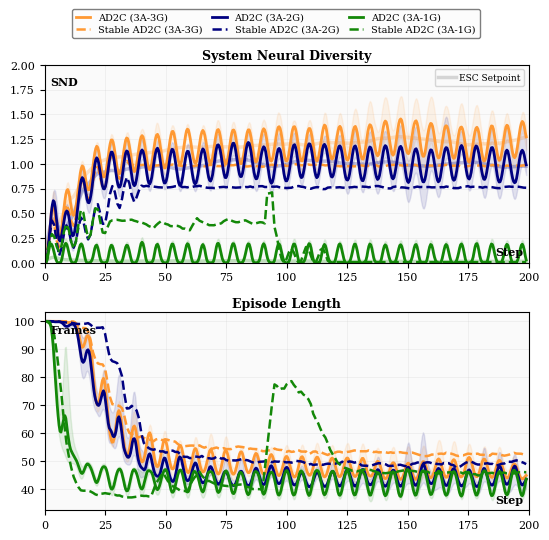

In [59]:
"""
Stability Analysis — Single Column (SND + Episode Length stacked vertically)
AD2C (ESC on) vs Stable AD2C (ESC off after convergence)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.lines as mlines
import glob
import os

# ============================================================
# STYLE
# ============================================================
matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman', 'Times New Roman', 'DejaVu Serif'],
    'text.usetex': False,
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'legend.fontsize': 7,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linewidth': 0.4,
    'axes.facecolor': '#fafafa',
})

# ============================================================
# CONFIG
# ============================================================
NAV_DATA_DIR = "navigation_data"
STAB_DATA_DIR = "stability_data"

COLORS = {
    "3A-3G": "#FF9933",
    "3A-2G": "#000080",
    "3A-1G": "#138808",
}

STYLE_AD2C   = {"linestyle": "-",  "linewidth": 2.0}
STYLE_STABLE = {"linestyle": "--", "linewidth": 1.8}

METRICS = {
    "snd":    "eval/agents/snd",
    "epl":    "eval/reward/episode_len_mean",
}
SETPOINT_COL = "esc/snd_setpoint"
STEP_COL = "_step"

SMOOTH_WINDOW = 5
SMOOTH_WINDOW_SND = 3

STABLE_FILES = {
    "3A-3G": "stable_ad2c_3a3g_0.csv",
    "3A-2G": "stable_ad2c_3a2g_0.csv",
    "3A-1G": "stable_ad2c_3a1g_0.csv",
}

TASKS = ["3A-3G", "3A-2G", "3A-1G"]

# ============================================================
# HELPERS
# ============================================================

def smooth(y, window=SMOOTH_WINDOW):
    if window <= 1 or len(y) < window:
        return y
    kernel = np.ones(window) / window
    padded = np.pad(y, (window // 2, window // 2), mode='edge')
    smoothed = np.convolve(padded, kernel, mode='valid')
    return smoothed[:len(y)]


def load_ad2c_seeds(nav_dir):
    data = {}
    for task in TASKS:
        pattern = os.path.join(nav_dir, f"ad2c_{task}_*.csv")
        files = sorted(glob.glob(pattern))
        if files:
            data[task] = [pd.read_csv(f) for f in files]
            print(f"  AD2C {task}: {len(files)} seeds")
    return data


def load_stable_runs(stab_dir):
    data = {}
    for task, fname in STABLE_FILES.items():
        fpath = os.path.join(stab_dir, fname)
        if os.path.exists(fpath):
            data[task] = pd.read_csv(fpath)
            print(f"  Stable {task}: {len(data[task])} rows")
        else:
            print(f"  MISSING: {fpath}")
    return data


def aggregate_seeds(dfs, metric_col, step_col=STEP_COL, n_points=500, smooth_window=SMOOTH_WINDOW):
    valid_dfs = []
    for df in dfs:
        if metric_col in df.columns and step_col in df.columns:
            sub = df[[step_col, metric_col]].dropna().sort_values(step_col)
            if len(sub) >= 2:
                valid_dfs.append(sub)

    if not valid_dfs:
        return None, None, None, None

    min_step = max(df[step_col].min() for df in valid_dfs)
    max_step = min(df[step_col].max() for df in valid_dfs)
    common_steps = np.linspace(min_step, max_step, n_points)

    interpolated = []
    for sub in valid_dfs:
        vals = np.interp(common_steps, sub[step_col].values, sub[metric_col].values)
        interpolated.append(vals)

    interpolated = np.array(interpolated)
    mean = np.mean(interpolated, axis=0)
    vmin = np.min(interpolated, axis=0)
    vmax = np.max(interpolated, axis=0)

    return common_steps, smooth(mean, smooth_window), smooth(vmin, smooth_window), smooth(vmax, smooth_window)


# ============================================================
# PLOTTING
# ============================================================

def set_corner_labels(ax, ylabel, xlabel=None):
    """Place y-label at top-left corner, x-label at bottom-right corner."""
    # Remove default axis labels
    ax.set_xlabel('')
    ax.set_ylabel('')
    
    # Y-label: top-left corner
    ax.annotate(ylabel, xy=(0, 0.97), xycoords='axes fraction',
                xytext=(4, -4), textcoords='offset points',
                fontsize=8, fontweight='bold',
                ha='left', va='top')
    
    # X-label: bottom-right corner
    if xlabel:
        ax.annotate(xlabel, xy=(1, 0), xycoords='axes fraction',
                    xytext=(-4, 4), textcoords='offset points',
                    fontsize=8, fontweight='bold',
                    ha='right', va='bottom')


def plot_metric(ax, ad2c_data, stable_data, metric_key, ylabel, title,
                ylim=None, show_setpoint=False, sw=SMOOTH_WINDOW,
                show_xlabel=True, xlabel="Step"):
    metric_col = METRICS[metric_key]

    for task in TASKS:
        color = COLORS[task]

        if task in ad2c_data:
            steps, mean, vmin, vmax = aggregate_seeds(
                ad2c_data[task], metric_col, smooth_window=sw)
            if steps is not None:
                ax.plot(steps, mean, color=color,
                        label=f"AD2C ({task})",
                        **STYLE_AD2C)
                ax.fill_between(steps, vmin, vmax, color=color, alpha=0.10)

                if show_setpoint:
                    sp_steps, sp_mean, _, _ = aggregate_seeds(
                        ad2c_data[task], SETPOINT_COL, smooth_window=11)
                    if sp_steps is not None:
                        ax.plot(sp_steps, sp_mean, color=color,
                                linewidth=2.5, alpha=0.25, zorder=1)

        if task in stable_data:
            df = stable_data[task]
            if metric_col in df.columns and STEP_COL in df.columns:
                sub = df[[STEP_COL, metric_col]].dropna().sort_values(STEP_COL)
                steps = sub[STEP_COL].values
                vals = smooth(sub[metric_col].values, window=sw)

                ax.plot(steps, vals, color=color,
                        label=f"Stable AD2C ({task})",
                        **STYLE_STABLE)

    # Corner-aligned labels
    set_corner_labels(ax, ylabel, xlabel=xlabel if show_xlabel else None)
    
    ax.set_title(title, fontweight='bold', fontsize=9, pad=4)
    ax.set_xlim(left=0, right=200)
    if ylim:
        ax.set_ylim(ylim)
    
    # Hide x tick labels for top plot
    if not show_xlabel:
        ax.set_xticklabels([])


def make_stability_figure(ad2c_data, stable_data, output_prefix="stability_nav"):
    fig, axes = plt.subplots(2, 1, figsize=(5.5, 5.5), constrained_layout=False)
    fig.subplots_adjust(left=0.08, right=0.96, bottom=0.06, top=0.87, hspace=0.25)

    # Top: SND
    plot_metric(axes[0], ad2c_data, stable_data, "snd",
                ylabel="SND",
                title="System Neural Diversity",
                ylim=(0, 2.0),
                show_setpoint=True,
                sw=SMOOTH_WINDOW_SND,
                show_xlabel=True)

    # Bottom: Episode Length
    plot_metric(axes[1], ad2c_data, stable_data, "epl",
                ylabel="Frames",
                title="Episode Length",
                show_xlabel=True,
                xlabel="Step")

    # ESC Setpoint legend on SND plot only
    sp_handle = mlines.Line2D([], [], color='gray', linewidth=2.5, alpha=0.3,
                               linestyle='-', label='ESC Setpoint')
    axes[0].legend(handles=[sp_handle], labels=['ESC Setpoint'],
                   loc='upper right', fontsize=6.5, frameon=True,
                   fancybox=True, framealpha=0.8, edgecolor='#cccccc',
                   handlelength=2.0, handletextpad=0.3)

    # Collect handles for fig legend
    label_to_handle = {}
    for ax in axes:
        h, l = ax.get_legend_handles_labels()
        for handle, label in zip(h, l):
            if label not in label_to_handle and label != 'ESC Setpoint':
                label_to_handle[label] = handle

    # Interleave for matplotlib's column-major fill
    row1 = ["AD2C (3A-3G)", "AD2C (3A-2G)", "AD2C (3A-1G)"]
    row2 = ["Stable AD2C (3A-3G)", "Stable AD2C (3A-2G)", "Stable AD2C (3A-1G)"]
    matplotlib_order = []
    for r1, r2 in zip(row1, row2):
        matplotlib_order.extend([r1, r2])

    ordered_handles = [label_to_handle[l] for l in matplotlib_order if l in label_to_handle]
    ordered_labels = [l for l in matplotlib_order if l in label_to_handle]

    legend = fig.legend(
        ordered_handles,
        ordered_labels,
        loc='upper center',
        bbox_to_anchor=(0.5, 0.98),
        ncol=3,
        fontsize=7,
        frameon=True,
        fancybox=True,
        edgecolor='black',
        framealpha=0.5,
        columnspacing=1.0,
        handlelength=1.5,
        borderpad=0.4,
        labelspacing=0.3
    )

    # # Title
    # fig.suptitle('Stability Analysis',
    #              fontsize=11, fontweight='bold', y=1.0)

    for ext in ['png', 'pdf']:
        outpath = f"{output_prefix}.{ext}"
        fig.savefig(outpath, dpi=300, bbox_inches='tight')
        print(f"Saved: {outpath}")

    plt.show()


if __name__ == "__main__":
    print("Loading AD2C baseline data...")
    ad2c_data = load_ad2c_seeds(NAV_DATA_DIR)

    print("\nLoading Stable AD2C data...")
    stable_data = load_stable_runs(STAB_DATA_DIR)

    print(f"\nPlotting stability analysis...")
    make_stability_figure(ad2c_data, stable_data)

# Balance Task. 

In [68]:
"""
Download the 3 missing DiCo balance runs.
Correct naming: bal_dico_3a{n}Mass_0
Project: Balance (not Navigation)
"""

import pandas as pd
import wandb
import os

ENTITY_PROJECT = "svarp-university-of-massachusetts-lowell/Balance"
OUTPUT_DIR = "balance_data"

DICO_RUNS = {
    "4M": "bal_dico_3a4Mass_0",
    "3M": "bal_dico_3a3Mass_0",
    "2M": "bal_dico_3a2Mass_0",
}

def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    api = wandb.Api()

    print(f"Fetching run list from {ENTITY_PROJECT}...")
    runs = api.runs(ENTITY_PROJECT)
    run_lookup = {run.name: run for run in runs}

    # Print all dico runs for debugging
    print("\nAvailable bal_dico runs:")
    for name in sorted(run_lookup.keys()):
        if "dico" in name.lower():
            print(f"  {name}")
    print()

    for task, run_name in DICO_RUNS.items():
        if run_name not in run_lookup:
            print(f"  MISSING: '{run_name}'")
            continue

        run = run_lookup[run_name]
        print(f"Downloading: dico / {task} / {run_name} ...", end=" ")

        df = run.history(samples=10000)

        safe_name = run_name.replace(".", "p").replace("-", "neg")
        filepath = os.path.join(OUTPUT_DIR, f"dico_{task}_{safe_name}.csv")
        df.to_csv(filepath, index=False)
        print(f"OK ({len(df)} rows)")

    print("\nDone! Now you should have all 21 CSVs in balance_data/.")

if __name__ == "__main__":
    main()

Fetching run list from svarp-university-of-massachusetts-lowell/Balance...

Available bal_dico runs:
  bal_dico_3a2Mass_0
  bal_dico_3a2Mass_0.3
  bal_dico_3a2Mass_0.5
  bal_dico_3a2Mass_0.8
  bal_dico_3a2Mass_1
  bal_dico_3a2Mass_1.3
  bal_dico_3a2Mass_1.5
  bal_dico_3a3Mass_0
  bal_dico_3a3Mass_0.3
  bal_dico_3a3Mass_0.5
  bal_dico_3a3Mass_0.8
  bal_dico_3a3Mass_1
  bal_dico_3a3Mass_1.3
  bal_dico_3a3Mass_1.5
  bal_dico_3a4Mass_0
  bal_dico_3a4Mass_0.3
  bal_dico_3a4Mass_0.5
  bal_dico_3a4Mass_0.8
  bal_dico_3a4Mass_1
  bal_dico_3a4Mass_1.3
  bal_dico_3a4Mass_1.5

Downloading: dico / 4M / bal_dico_3a4Mass_0 ... OK (200 rows)
Downloading: dico / 3M / bal_dico_3a3Mass_0 ... OK (200 rows)
Downloading: dico / 2M / bal_dico_3a2Mass_0 ... OK (200 rows)

Done! Now you should have all 21 CSVs in balance_data/.


Loading balance data...
  ad2c / 4M: 5 seeds
  ad2c / 3M: 5 seeds
  ad2c / 2M: 5 seeds
  dico / 4M: 1 runs
  dico / 3M: 1 runs
  dico / 2M: 1 runs
  unconstrained / 4M: 1 runs
  unconstrained / 3M: 1 runs
  unconstrained / 2M: 1 runs

Loaded 9 method-task combinations.

Plotting balance results...


Saved: balance_results.png
Saved: balance_results.pdf


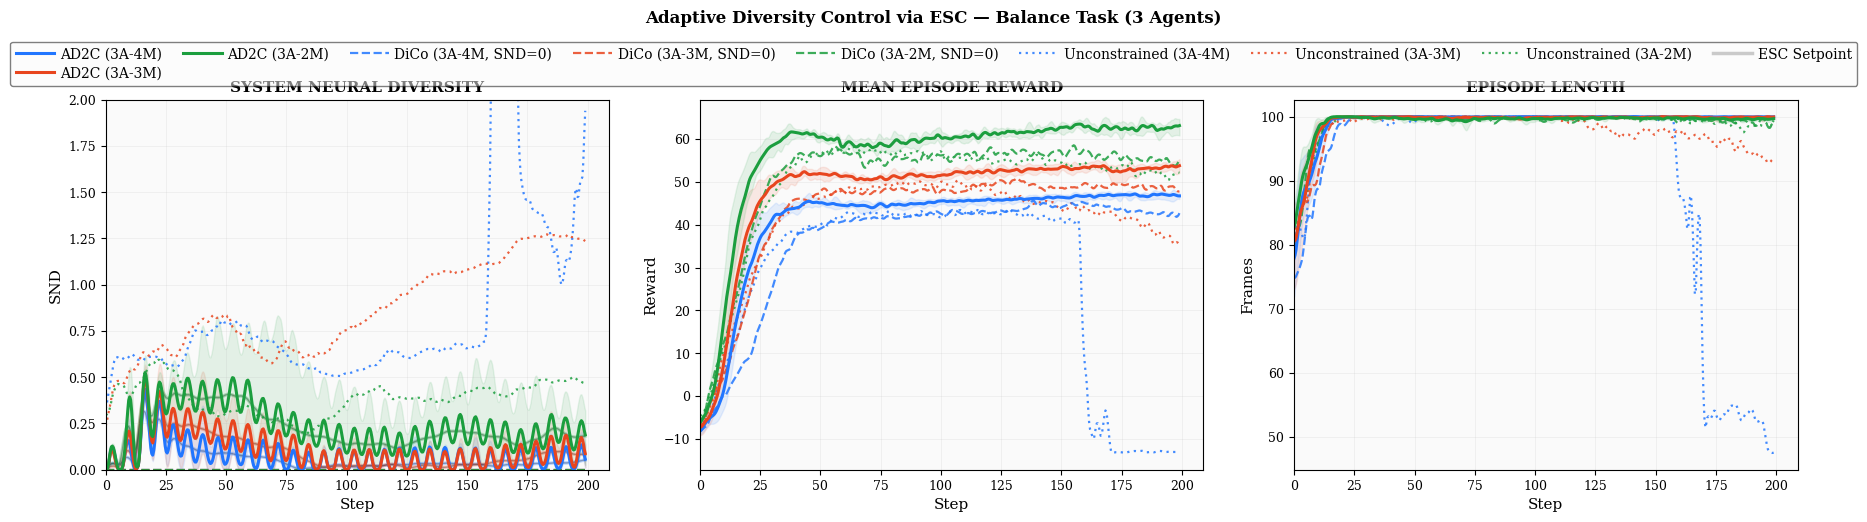

In [70]:
"""
Plot Balance Task Results: AD2C vs DiCo vs Unconstrained
3 subplots: SND, Reward, Episode Length
Same style as Navigation plot for visual consistency.

Task variants: 4M (4 unique masses), 3M, 2M
Colors: blue/red-orange/green by task (matching navigation)
Line styles: solid (AD2C), dashed (DiCo), dotted (Unconstrained)

Usage:
  python plot_balance.py
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.lines as mlines
import glob
import os

# ============================================================
# STYLE — same as navigation plot
# ============================================================
matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman', 'Times New Roman', 'DejaVu Serif'],
    'text.usetex': False,
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'legend.fontsize': 8,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linewidth': 0.4,
    'axes.facecolor': '#fafafa',
})

# ============================================================
# CONFIG
# ============================================================
DATA_DIR = "balance_data"

# Colors — same scheme as navigation for consistency
COLORS = {
    "4M": "#2176FF",   # blue (most diverse masses)
    "3M": "#E8451E",   # red-orange
    "2M": "#1B9E3E",   # green (least diverse)
}

LINE_STYLES = {
    "ad2c":          {"linestyle": "-",       "linewidth": 2.2, "alpha": 1.0},
    "dico":          {"linestyle": "--",      "linewidth": 1.6, "alpha": 0.85},
    "unconstrained": {"linestyle": (0,(1,2)), "linewidth": 1.6, "alpha": 0.85},
}

LABELS = {
    ("ad2c", "4M"):          "AD2C (3A-4M)",
    ("ad2c", "3M"):          "AD2C (3A-3M)",
    ("ad2c", "2M"):          "AD2C (3A-2M)",
    ("dico", "4M"):          "DiCo (3A-4M, SND=0)",
    ("dico", "3M"):          "DiCo (3A-3M, SND=0)",
    ("dico", "2M"):          "DiCo (3A-2M, SND=0)",
    ("unconstrained", "4M"): "Unconstrained (3A-4M)",
    ("unconstrained", "3M"): "Unconstrained (3A-3M)",
    ("unconstrained", "2M"): "Unconstrained (3A-2M)",
}

LEGEND_ORDER = [
    ("ad2c", "4M"), ("ad2c", "3M"), ("ad2c", "2M"),
    ("dico", "4M"), ("dico", "3M"), ("dico", "2M"),
    ("unconstrained", "4M"), ("unconstrained", "3M"), ("unconstrained", "2M"),
]

# Metric columns — same as navigation (adjust if balance uses different keys)
METRICS = {
    "snd":    "eval/agents/snd",
    "reward": "eval/agents/reward/episode_reward_mean",
    "epl":    "eval/reward/episode_len_mean",
}

SETPOINT_COL = "esc/snd_setpoint"
STEP_COL = "_step"

SMOOTH_WINDOW = 5
SMOOTH_WINDOW_SND = 3

TASKS = ["4M", "3M", "2M"]

# ============================================================
# DATA LOADING
# ============================================================

def load_runs(data_dir):
    """Load all CSVs organized by (method, task)."""
    data = {}

    # AD2C: multiple seeds
    for task in TASKS:
        pattern = os.path.join(data_dir, f"ad2c_{task}_*.csv")
        files = sorted(glob.glob(pattern))
        if files:
            data[("ad2c", task)] = [pd.read_csv(f) for f in files]
            print(f"  ad2c / {task}: {len(files)} seeds")

    # DiCo: single run per task
    for task in TASKS:
        pattern = os.path.join(data_dir, f"dico_{task}_*.csv")
        files = sorted(glob.glob(pattern))
        if files:
            data[("dico", task)] = [pd.read_csv(f) for f in files]
            print(f"  dico / {task}: {len(files)} runs")

    # Unconstrained: single run per task
    for task in TASKS:
        pattern = os.path.join(data_dir, f"unconstrained_{task}_*.csv")
        files = sorted(glob.glob(pattern))
        if files:
            data[("unconstrained", task)] = [pd.read_csv(f) for f in files]
            print(f"  unconstrained / {task}: {len(files)} runs")

    return data


def smooth(y, window=SMOOTH_WINDOW):
    if window <= 1 or len(y) < window:
        return y
    kernel = np.ones(window) / window
    padded = np.pad(y, (window // 2, window // 2), mode='edge')
    smoothed = np.convolve(padded, kernel, mode='valid')
    return smoothed[:len(y)]


def aggregate_seeds(dfs, metric_col, step_col=STEP_COL, n_points=500, smooth_window=SMOOTH_WINDOW):
    valid_dfs = []
    for df in dfs:
        if metric_col in df.columns and step_col in df.columns:
            sub = df[[step_col, metric_col]].dropna().sort_values(step_col)
            if len(sub) >= 2:
                valid_dfs.append(sub)

    if not valid_dfs:
        return None, None, None, None

    min_step = max(df[step_col].min() for df in valid_dfs)
    max_step = min(df[step_col].max() for df in valid_dfs)
    common_steps = np.linspace(min_step, max_step, n_points)

    interpolated = []
    for sub in valid_dfs:
        vals = np.interp(common_steps, sub[step_col].values, sub[metric_col].values)
        interpolated.append(vals)

    interpolated = np.array(interpolated)
    mean = np.mean(interpolated, axis=0)
    vmin = np.min(interpolated, axis=0)
    vmax = np.max(interpolated, axis=0)

    return common_steps, smooth(mean, smooth_window), smooth(vmin, smooth_window), smooth(vmax, smooth_window)


def aggregate_setpoint(dfs, step_col=STEP_COL, n_points=500):
    valid_dfs = []
    for df in dfs:
        if SETPOINT_COL in df.columns and step_col in df.columns:
            sub = df[[step_col, SETPOINT_COL]].dropna().sort_values(step_col)
            if len(sub) >= 2:
                valid_dfs.append(sub)

    if not valid_dfs:
        return None, None

    min_step = max(df[step_col].min() for df in valid_dfs)
    max_step = min(df[step_col].max() for df in valid_dfs)
    common_steps = np.linspace(min_step, max_step, n_points)

    interpolated = []
    for sub in valid_dfs:
        vals = np.interp(common_steps, sub[step_col].values, sub[SETPOINT_COL].values)
        interpolated.append(vals)

    interpolated = np.array(interpolated)
    mean = np.mean(interpolated, axis=0)

    return common_steps, smooth(mean, window=11)


# ============================================================
# PLOTTING
# ============================================================

def plot_metric(ax, data, metric_key, ylabel, title, ylim=None,
                show_setpoint=False, smooth_window=SMOOTH_WINDOW):
    metric_col = METRICS[metric_key]

    # Plot order: unconstrained (back), dico (mid), ad2c (front)
    plot_order = [
        ("unconstrained", "4M"), ("unconstrained", "3M"), ("unconstrained", "2M"),
        ("dico", "4M"), ("dico", "3M"), ("dico", "2M"),
        ("ad2c", "4M"), ("ad2c", "3M"), ("ad2c", "2M"),
    ]

    for method, task in plot_order:
        key = (method, task)
        if key not in data:
            continue

        steps, mean, vmin, vmax = aggregate_seeds(data[key], metric_col,
                                                   smooth_window=smooth_window)
        if steps is None:
            continue

        color = COLORS[task]
        style = LINE_STYLES[method]
        label = LABELS.get(key, f"{method} {task}")

        ax.plot(steps, mean, color=color, label=label,
                linestyle=style["linestyle"],
                linewidth=style["linewidth"],
                alpha=style["alpha"])

        if method == "ad2c":
            ax.fill_between(steps, vmin, vmax, color=color, alpha=0.10)

    # Setpoint overlay for AD2C
    if show_setpoint:
        for task in TASKS:
            key = ("ad2c", task)
            if key not in data:
                continue
            sp_steps, sp_mean = aggregate_setpoint(data[key])
            if sp_steps is None:
                continue
            ax.plot(sp_steps, sp_mean, color='black',
                    linewidth=1.0, alpha=0.35, zorder=1)
            ax.plot(sp_steps, sp_mean, color=COLORS[task],
                    linewidth=2.5, alpha=0.3, zorder=1)

    ax.set_xlabel("Step")
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlim(left=0)
    if ylim:
        ax.set_ylim(ylim)


def make_balance_figure(data, output_prefix="balance"):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=False)
    fig.subplots_adjust(left=0.04, right=0.98, bottom=0.08, top=0.82, wspace=0.18)

    # Plot 1: SND
    plot_metric(axes[0], data, "snd",
                ylabel="SND",
                title="SYSTEM NEURAL DIVERSITY",
                ylim=(0, 2.0),
                show_setpoint=True,
                smooth_window=SMOOTH_WINDOW_SND)

    # Plot 2: Reward
    plot_metric(axes[1], data, "reward",
                ylabel="Reward",
                title="MEAN EPISODE REWARD")

    # Plot 3: Episode Length
    plot_metric(axes[2], data, "epl",
                ylabel="Frames",
                title="EPISODE LENGTH")

    # Build legend — reorder properly
    raw_handles, raw_labels = axes[0].get_legend_handles_labels()
    label_to_handle = dict(zip(raw_labels, raw_handles))

    ordered_handles = []
    ordered_labels = []
    for key in LEGEND_ORDER:
        lbl = LABELS.get(key)
        if lbl and lbl in label_to_handle:
            ordered_handles.append(label_to_handle[lbl])
            ordered_labels.append(lbl)

    # Add setpoint entry
    sp_handle = mlines.Line2D([], [], color='gray', linewidth=2.5, alpha=0.4,
                               linestyle='-', label='ESC Setpoint')
    ordered_handles.append(sp_handle)
    ordered_labels.append('ESC Setpoint')

    # Two-line legend
    fig.legend(ordered_handles, ordered_labels,
               loc='upper center',
               ncol=9,
               bbox_to_anchor=(0.5, 0.95),
               fontsize=10,
               frameon=True,
               fancybox=True,
               edgecolor='black',
               framealpha=0.5,
               columnspacing=1.5,
               handlelength=2.8,
               handletextpad=0.4,
               borderpad=0.4,
               labelspacing=0.35)

    fig.suptitle(
        'Adaptive Diversity Control via ESC — Balance Task (3 Agents)',
        fontsize=12, fontweight='bold', y=1.0)

    for ext in ['png', 'pdf']:
        outpath = f"{output_prefix}_results.{ext}"
        fig.savefig(outpath, dpi=300, bbox_inches='tight')
        print(f"Saved: {outpath}")

    plt.show()


if __name__ == "__main__":
    print("Loading balance data...")
    data = load_runs(DATA_DIR)
    print(f"\nLoaded {len(data)} method-task combinations.\n")

    print("Plotting balance results...")
    make_balance_figure(data)

# PLot 1: Combined Layout

Loading navigation data...
  nav ad2c / 3A-3G: 5 seeds
  nav ad2c / 3A-2G: 5 seeds
  nav ad2c / 3A-1G: 5 seeds
  nav dico / 3A-3G: 1 run
  nav dico / 3A-2G: 1 run
  nav dico / 3A-1G: 1 run
  nav unconstrained / 3A-3G: 1 runs
  nav unconstrained / 3A-2G: 1 runs
  nav unconstrained / 3A-1G: 1 runs
  Loaded 9 nav method-task combos.

Loading balance data...
  bal ad2c / 4M: 5 seeds
  bal ad2c / 3M: 5 seeds
  bal ad2c / 2M: 5 seeds
  bal dico / 4M: 1 runs
  bal dico / 3M: 1 runs
  bal dico / 2M: 1 runs
  bal unconstrained / 4M: 1 runs
  bal unconstrained / 3M: 1 runs
  bal unconstrained / 2M: 1 runs
  Loaded 9 bal method-task combos.

Plotting combined figure...
Saved: fig1_combined.png
Saved: fig1_combined.pdf


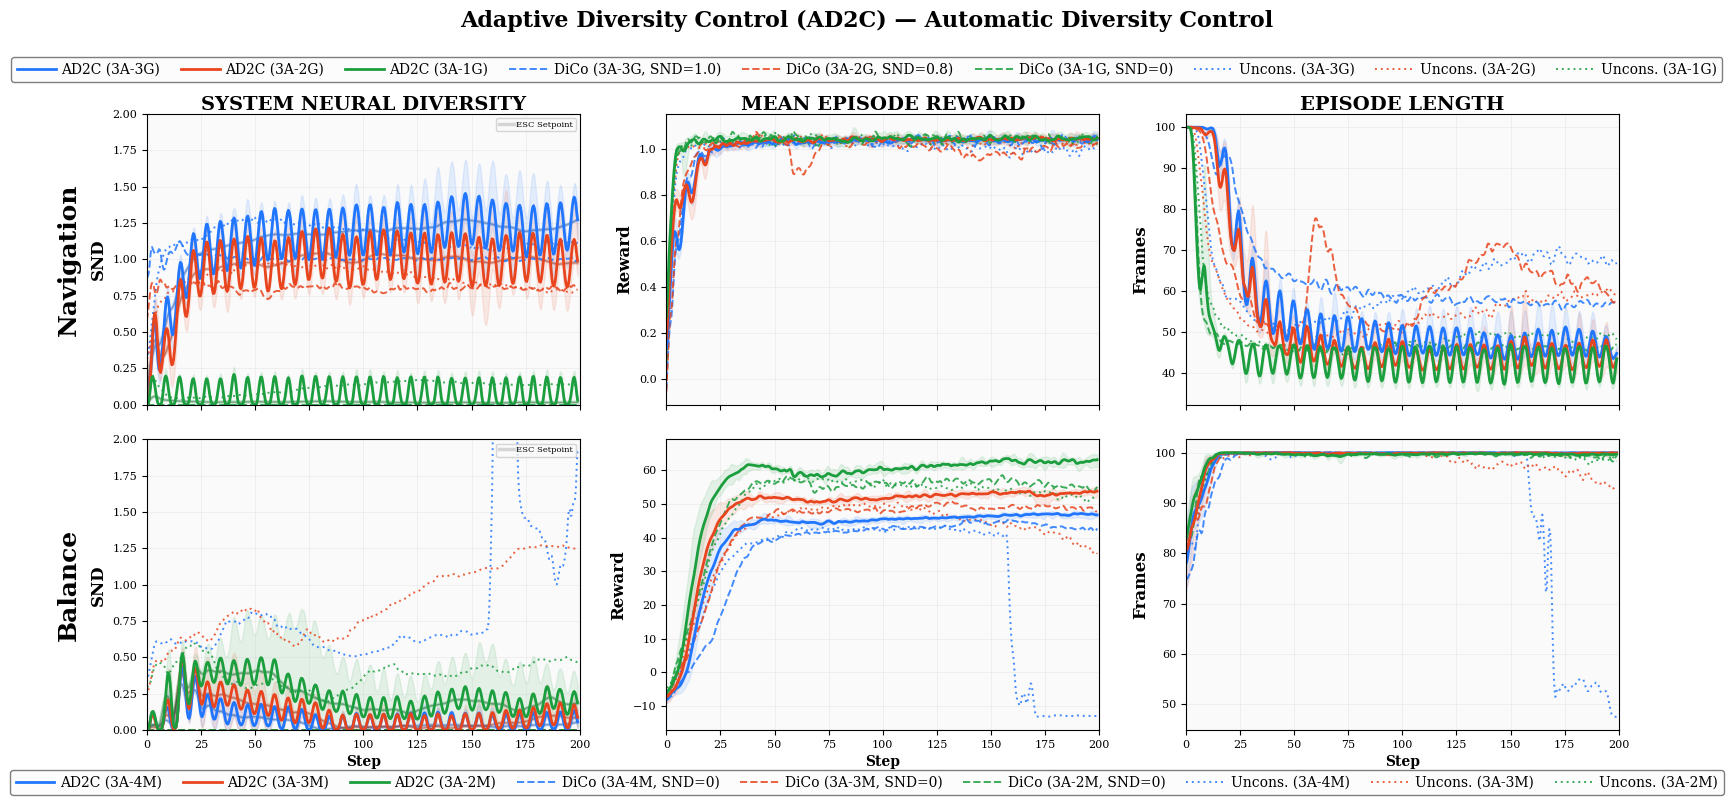

In [86]:
"""
Figure 1: Combined Navigation + Balance Results
Row 1: Navigation (SND, Reward, EPL) — 3 agents, 3 task variants (1G, 2G, 3G)
Row 2: Balance (SND, Reward, EPL) — 3 agents, 3 mass variants (2M, 3M, 4M)

AD2C vs DiCo vs Unconstrained across all tasks.

Usage:
  python plot_combined.py
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.lines as mlines
import glob
import os

# ============================================================
# STYLE
# ============================================================
matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman', 'Times New Roman', 'DejaVu Serif'],
    'text.usetex': False,
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'legend.fontsize': 7,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linewidth': 0.4,
    'axes.facecolor': '#fafafa',
})

# ============================================================
# SHARED CONFIG
# ============================================================
STEP_COL = "_step"
SETPOINT_COL = "esc/snd_setpoint"
METRICS = {
    "snd":    "eval/agents/snd",
    "reward": "eval/agents/reward/episode_reward_mean",
    "epl":    "eval/reward/episode_len_mean",
}
SMOOTH_WINDOW = 5
SMOOTH_WINDOW_SND = 3

LINE_STYLES = {
    "ad2c":          {"linestyle": "-",       "linewidth": 2.0, "alpha": 1.0},
    "dico":          {"linestyle": "--",      "linewidth": 1.4, "alpha": 0.85},
    "unconstrained": {"linestyle": (0,(1,2)), "linewidth": 1.4, "alpha": 0.85},
}

# ============================================================
# NAVIGATION CONFIG
# ============================================================
NAV_DATA_DIR = "navigation_data"
NAV_COLORS = {
    "3A-3G": "#2176FF",
    "3A-2G": "#E8451E",
    "3A-1G": "#1B9E3E",
}
NAV_LABELS = {
    ("ad2c", "3A-3G"):          "AD2C (3A-3G)",
    ("ad2c", "3A-2G"):          "AD2C (3A-2G)",
    ("ad2c", "3A-1G"):          "AD2C (3A-1G)",
    ("dico", "3A-3G"):          "DiCo (3A-3G, SND=1.0)",
    ("dico", "3A-2G"):          "DiCo (3A-2G, SND=0.8)",
    ("dico", "3A-1G"):          "DiCo (3A-1G, SND=0)",
    ("unconstrained", "3A-3G"): "Uncons. (3A-3G)",
    ("unconstrained", "3A-2G"): "Uncons. (3A-2G)",
    ("unconstrained", "3A-1G"): "Uncons. (3A-1G)",
}
NAV_LEGEND_ORDER = [
    ("ad2c", "3A-3G"), ("ad2c", "3A-2G"), ("ad2c", "3A-1G"),
    ("dico", "3A-3G"), ("dico", "3A-2G"), ("dico", "3A-1G"),
    ("unconstrained", "3A-3G"), ("unconstrained", "3A-2G"), ("unconstrained", "3A-1G"),
]
NAV_TASKS = ["3A-3G", "3A-2G", "3A-1G"]

# ============================================================
# BALANCE CONFIG
# ============================================================
BAL_DATA_DIR = "balance_data"
BAL_COLORS = {
    "4M": "#2176FF",
    "3M": "#E8451E",
    "2M": "#1B9E3E",
}
BAL_LABELS = {
    ("ad2c", "4M"):          "AD2C (3A-4M)",
    ("ad2c", "3M"):          "AD2C (3A-3M)",
    ("ad2c", "2M"):          "AD2C (3A-2M)",
    ("dico", "4M"):          "DiCo (3A-4M, SND=0)",
    ("dico", "3M"):          "DiCo (3A-3M, SND=0)",
    ("dico", "2M"):          "DiCo (3A-2M, SND=0)",
    ("unconstrained", "4M"): "Uncons. (3A-4M)",
    ("unconstrained", "3M"): "Uncons. (3A-3M)",
    ("unconstrained", "2M"): "Uncons. (3A-2M)",
}
BAL_LEGEND_ORDER = [
    ("ad2c", "4M"), ("ad2c", "3M"), ("ad2c", "2M"),
    ("dico", "4M"), ("dico", "3M"), ("dico", "2M"),
    ("unconstrained", "4M"), ("unconstrained", "3M"), ("unconstrained", "2M"),
]
BAL_TASKS = ["4M", "3M", "2M"]

# ============================================================
# HELPERS
# ============================================================

def smooth(y, window=SMOOTH_WINDOW):
    if window <= 1 or len(y) < window:
        return y
    kernel = np.ones(window) / window
    padded = np.pad(y, (window // 2, window // 2), mode='edge')
    smoothed = np.convolve(padded, kernel, mode='valid')
    return smoothed[:len(y)]


def aggregate_seeds(dfs, metric_col, step_col=STEP_COL, n_points=500, smooth_window=SMOOTH_WINDOW):
    valid_dfs = []
    for df in dfs:
        if metric_col in df.columns and step_col in df.columns:
            sub = df[[step_col, metric_col]].dropna().sort_values(step_col)
            if len(sub) >= 2:
                valid_dfs.append(sub)
    if not valid_dfs:
        return None, None, None, None
    min_step = max(df[step_col].min() for df in valid_dfs)
    max_step = min(df[step_col].max() for df in valid_dfs)
    common_steps = np.linspace(min_step, max_step, n_points)
    interpolated = []
    for sub in valid_dfs:
        vals = np.interp(common_steps, sub[step_col].values, sub[metric_col].values)
        interpolated.append(vals)
    interpolated = np.array(interpolated)
    mean = np.mean(interpolated, axis=0)
    vmin = np.min(interpolated, axis=0)
    vmax = np.max(interpolated, axis=0)
    return common_steps, smooth(mean, smooth_window), smooth(vmin, smooth_window), smooth(vmax, smooth_window)


def aggregate_setpoint(dfs, step_col=STEP_COL, n_points=500):
    valid_dfs = []
    for df in dfs:
        if SETPOINT_COL in df.columns and step_col in df.columns:
            sub = df[[step_col, SETPOINT_COL]].dropna().sort_values(step_col)
            if len(sub) >= 2:
                valid_dfs.append(sub)
    if not valid_dfs:
        return None, None
    min_step = max(df[step_col].min() for df in valid_dfs)
    max_step = min(df[step_col].max() for df in valid_dfs)
    common_steps = np.linspace(min_step, max_step, n_points)
    interpolated = []
    for sub in valid_dfs:
        vals = np.interp(common_steps, sub[step_col].values, sub[SETPOINT_COL].values)
        interpolated.append(vals)
    interpolated = np.array(interpolated)
    return common_steps, smooth(np.mean(interpolated, axis=0), window=11)


# ============================================================
# DATA LOADING
# ============================================================

def load_nav_data():
    data = {}
    for task in NAV_TASKS:
        pattern = os.path.join(NAV_DATA_DIR, f"ad2c_{task}_*.csv")
        files = sorted(glob.glob(pattern))
        if files:
            data[("ad2c", task)] = [pd.read_csv(f) for f in files]
            print(f"  nav ad2c / {task}: {len(files)} seeds")

    dico_files = {
        "3A-3G": "dico_3A-3G_nav_dico_3a3g_1.csv",
        "3A-2G": "dico_3A-2G_nav_dico_3a2g_0p8.csv",
        "3A-1G": "dico_3A-1G_nav_dico_3a1g_0.csv",
    }
    for task, fname in dico_files.items():
        fpath = os.path.join(NAV_DATA_DIR, fname)
        if os.path.exists(fpath):
            data[("dico", task)] = [pd.read_csv(fpath)]
            print(f"  nav dico / {task}: 1 run")

    for task in NAV_TASKS:
        pattern = os.path.join(NAV_DATA_DIR, f"unconstrained_{task}_*.csv")
        files = sorted(glob.glob(pattern))
        if files:
            data[("unconstrained", task)] = [pd.read_csv(f) for f in files]
            print(f"  nav unconstrained / {task}: {len(files)} runs")
    return data


def load_bal_data():
    data = {}
    for task in BAL_TASKS:
        pattern = os.path.join(BAL_DATA_DIR, f"ad2c_{task}_*.csv")
        files = sorted(glob.glob(pattern))
        if files:
            data[("ad2c", task)] = [pd.read_csv(f) for f in files]
            print(f"  bal ad2c / {task}: {len(files)} seeds")

    for task in BAL_TASKS:
        pattern = os.path.join(BAL_DATA_DIR, f"dico_{task}_*.csv")
        files = sorted(glob.glob(pattern))
        if files:
            data[("dico", task)] = [pd.read_csv(f) for f in files]
            print(f"  bal dico / {task}: {len(files)} runs")

    for task in BAL_TASKS:
        pattern = os.path.join(BAL_DATA_DIR, f"unconstrained_{task}_*.csv")
        files = sorted(glob.glob(pattern))
        if files:
            data[("unconstrained", task)] = [pd.read_csv(f) for f in files]
            print(f"  bal unconstrained / {task}: {len(files)} runs")
    return data


# ============================================================
# PLOTTING
# ============================================================

def plot_metric(ax, data, tasks, colors, labels_dict, metric_key, ylabel, title,
                ylim=None, show_setpoint=False, smooth_window=SMOOTH_WINDOW,
                show_xlabel=True):
    metric_col = METRICS[metric_key]

    # Plot order: unconstrained (back), dico (mid), ad2c (front)
    for method in ["unconstrained", "dico", "ad2c"]:
        for task in tasks:
            key = (method, task)
            if key not in data:
                continue
            steps, mean, vmin, vmax = aggregate_seeds(
                data[key], metric_col, smooth_window=smooth_window)
            if steps is None:
                continue
            color = colors[task]
            style = LINE_STYLES[method]
            label = labels_dict.get(key, f"{method} {task}")
            ax.plot(steps, mean, color=color, label=label,
                    linestyle=style["linestyle"],
                    linewidth=style["linewidth"],
                    alpha=style["alpha"])
            if method == "ad2c":
                ax.fill_between(steps, vmin, vmax, color=color, alpha=0.10)

    # Setpoint overlay
    if show_setpoint:
        for task in tasks:
            key = ("ad2c", task)
            if key not in data:
                continue
            sp_steps, sp_mean = aggregate_setpoint(data[key])
            if sp_steps is None:
                continue
            ax.plot(sp_steps, sp_mean, color='black',
                    linewidth=1.0, alpha=0.35, zorder=1)
            ax.plot(sp_steps, sp_mean, color=colors[task],
                    linewidth=2.5, alpha=0.3, zorder=1)

    if show_xlabel:
        ax.set_xlabel("Step", fontweight='bold')
    else:
        ax.set_xticklabels([])
    ax.set_ylabel(ylabel, fontweight='bold', fontsize=12)
    ax.set_title(title, fontweight='bold', fontsize=14, pad=2)
    ax.set_xlim(left=0, right=200)
    if ylim:
        ax.set_ylim(ylim)


def build_ordered_legend(ax, legend_order, labels_dict):
    """Extract handles from ax in the specified order."""
    raw_handles, raw_labels = ax.get_legend_handles_labels()
    label_to_handle = dict(zip(raw_labels, raw_handles))
    ordered_handles = []
    ordered_labels = []
    for key in legend_order:
        lbl = labels_dict.get(key)
        if lbl and lbl in label_to_handle:
            ordered_handles.append(label_to_handle[lbl])
            ordered_labels.append(lbl)
    return ordered_handles, ordered_labels


def make_combined_figure(nav_data, bal_data, output_prefix="fig1_combined"):
    fig, axes = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=False)
    fig.subplots_adjust(left=0.05, right=0.97, bottom=0.10, top=0.87,
                        wspace=0.20, hspace=0.12)

    # ---- Row 1: Navigation (titles on top, no x-labels) ----
    plot_metric(axes[0, 0], nav_data, NAV_TASKS, NAV_COLORS, NAV_LABELS, "snd",
                ylabel="SND", title="SYSTEM NEURAL DIVERSITY",
                ylim=(0, 2.0), show_setpoint=True,
                smooth_window=SMOOTH_WINDOW_SND, show_xlabel=False)

    plot_metric(axes[0, 1], nav_data, NAV_TASKS, NAV_COLORS, NAV_LABELS, "reward",
                ylabel="Reward", title="MEAN EPISODE REWARD",
                show_xlabel=False)

    plot_metric(axes[0, 2], nav_data, NAV_TASKS, NAV_COLORS, NAV_LABELS, "epl",
                ylabel="Frames", title="EPISODE LENGTH",
                show_xlabel=False)

    # ESC Setpoint mini-legend on nav SND plot
    sp_handle = mlines.Line2D([], [], color='gray', linewidth=2.5, alpha=0.3,
                               linestyle='-', label='ESC Setpoint')
    axes[0, 0].legend(handles=[sp_handle], labels=['ESC Setpoint'],
                       loc='upper right', fontsize=6, frameon=True,
                       fancybox=True, framealpha=0.8, edgecolor='#cccccc',
                       handlelength=1.8, handletextpad=0.3, borderpad=0.3)

    # ---- Row 2: Balance (no titles, x-labels at bottom) ----
    plot_metric(axes[1, 0], bal_data, BAL_TASKS, BAL_COLORS, BAL_LABELS, "snd",
                ylabel="SND", title="",
                ylim=(0, 2.0), show_setpoint=True,
                smooth_window=SMOOTH_WINDOW_SND)

    plot_metric(axes[1, 1], bal_data, BAL_TASKS, BAL_COLORS, BAL_LABELS, "reward",
                ylabel="Reward", title="")

    plot_metric(axes[1, 2], bal_data, BAL_TASKS, BAL_COLORS, BAL_LABELS, "epl",
                ylabel="Frames", title="")

    # ESC Setpoint mini-legend on balance SND plot
    axes[1, 0].legend(handles=[sp_handle], labels=['ESC Setpoint'],
                       loc='upper right', fontsize=6, frameon=True,
                       fancybox=True, framealpha=0.8, edgecolor='#cccccc',
                       handlelength=1.8, handletextpad=0.3, borderpad=0.3)

    # ---- Row labels on left ----
    axes[0, 0].annotate('Navigation', xy=(-0.18, 0.5),
                         xycoords='axes fraction', fontsize=18,
                         fontweight='bold', rotation=90,
                         ha='center', va='center')
    axes[1, 0].annotate('Balance', xy=(-0.18, 0.5),
                         xycoords='axes fraction', fontsize=18,
                         fontweight='bold', rotation=90,
                         ha='center', va='center')

    # ---- Navigation legend (top, no title) ----
    nav_handles, nav_labels = build_ordered_legend(
        axes[0, 0], NAV_LEGEND_ORDER, NAV_LABELS)

    fig.legend(nav_handles, nav_labels,
               loc='upper center',
               ncol=9,
               bbox_to_anchor=(0.5, 0.95),
               fontsize=10,
               frameon=True,
               fancybox=True,
               edgecolor='black',
               framealpha=0.5,
               columnspacing=1.5,
               handlelength=2.8,
               handletextpad=0.4,
               borderpad=0.4,
               labelspacing=0.35)

    # ---- Balance legend (below balance plots, no title) ----
    bal_handles, bal_labels = build_ordered_legend(
        axes[1, 0], BAL_LEGEND_ORDER, BAL_LABELS)

    fig.legend(bal_handles, bal_labels,
               loc='lower center',
               ncol=9,
               bbox_to_anchor=(0.5, 0.01),
               fontsize=10,
               frameon=True,
               fancybox=True,
               edgecolor='black',
               framealpha=0.5,
               columnspacing=1.5,
               handlelength=2.8,
               handletextpad=0.4,
               borderpad=0.4,
               labelspacing=0.35)

    # ---- Title ----
    fig.suptitle(
        'Adaptive Diversity Control (AD2C) — Automatic Diversity Control',
        fontsize=16, fontweight='bold', y=1.0)

    # ---- Save ----
    for ext in ['png', 'pdf']:
        outpath = f"{output_prefix}.{ext}"
        fig.savefig(outpath, dpi=300, bbox_inches='tight')
        print(f"Saved: {outpath}")

    plt.show()


# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":
    print("Loading navigation data...")
    nav_data = load_nav_data()
    print(f"  Loaded {len(nav_data)} nav method-task combos.\n")

    print("Loading balance data...")
    bal_data = load_bal_data()
    print(f"  Loaded {len(bal_data)} bal method-task combos.\n")

    print("Plotting combined figure...")
    make_combined_figure(nav_data, bal_data)

Saved task_environments.png and .pdf


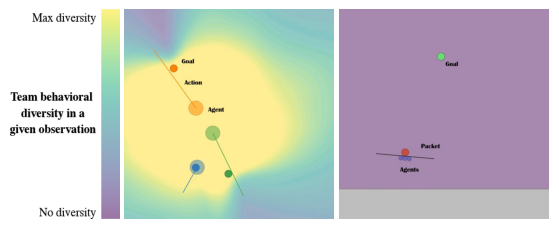

In [104]:
"""
Combine task environment images: Diversity colorbar + Navigation snapshot + Balance snapshot
Matches width of the combined plot figure (16 inches).
"""

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib
import numpy as np

matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman', 'Times New Roman', 'DejaVu Serif'],
    'font.size': 10,
})

# ============================================================
# CONFIG — update these paths to your local image locations
# ============================================================
IMG_DIVERSITY = "nav_agent_dis.png"
IMG_NAV = "nav_3a3g_snapshot.jpg"
IMG_BAL = "balance_snapshot.jpg"

# ============================================================
# AUTO-CROP whitespace
# ============================================================
def autocrop(img, threshold=0.95):
    """Remove near-white borders from an image."""
    if img.ndim == 3 and img.shape[2] == 4:
        gray = img[:, :, :3].mean(axis=2)
    else:
        gray = img.mean(axis=2) if img.ndim == 3 else img
    if gray.max() > 1:
        gray = gray / 255.0
    rows = np.where(gray.min(axis=1) < threshold)[0]
    cols = np.where(gray.min(axis=0) < threshold)[0]
    if len(rows) == 0 or len(cols) == 0:
        return img
    return img[rows[0]:rows[-1]+1, cols[0]:cols[-1]+1]

# ============================================================
# PLOT
# ============================================================
img_diversity = autocrop(mpimg.imread(IMG_DIVERSITY))
img_nav = mpimg.imread(IMG_NAV)
img_bal = mpimg.imread(IMG_BAL)

fig, axes = plt.subplots(1, 3, figsize=(5.5, 2.5),
                          gridspec_kw={'width_ratios': [0.52, 1.0, 1.0]})
fig.subplots_adjust(left=0.01, right=0.99, bottom=0.01, top=0.99, wspace=0.03)

axes[0].imshow(img_diversity)
axes[0].axis('off')

axes[1].imshow(img_nav, aspect='equal')
axes[1].axis('off')

axes[2].imshow(img_bal, aspect='equal')
axes[2].axis('off')

# fig.suptitle('Task Environments', fontsize=14, fontweight='bold', y=0.96)

plt.savefig('task_environments.png', dpi=300, bbox_inches='tight', pad_inches=0.05)
plt.savefig('task_environments.pdf', dpi=300, bbox_inches='tight', pad_inches=0.05)
print("Saved task_environments.png and .pdf")
plt.show()